# Notebook 4 - Graph Analytics

**Project phase:** Formula 1 Big Data Analysis with PySpark  
**Spark components:** GraphFrames · PageRank · ConnectedComponents · BFS · TriangleCount · Motif Finding  
**Goal:** Model the F1 ecosystem as three graphs to reveal structural patterns in driver relationships, constructor lineage, and the talent market.

1. **Driver Teammate Network** — Who are the most central and embedded drivers in F1 history?
2. **Constructor Lineage DAG** — How do today's teams trace back through acquisitions and rebranding?
3. **Driver–Constructor Bipartite Network** — Which constructors most amplified driver careers?

## 1. Environment Installation (Run Once & Restart)
**IMPORTANT INSTRUCTIONS:** Run this cell *first*. When it finishes, Google Colab will prompt you to **Restart Session**. Click Restart. Once the session has restarted, do NOT run this cell again. Move straight to step 2.

In [1]:
!pip uninstall -y pyspark
!pip install --no-cache-dir pyspark==3.5.1 graphframes

Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 221.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488493 sha256=3ae7cf39f5d6d76b111bb68eb802eaec5cbb5776763923910ee1e8fce3bc4342
  Stored in directory: /tmp/pip-ephem-wheel-cache-54lgrj7e/wheels/b1/91/5f/283b53010a8016a4ff1c4a1edd99bbe73afacb099645b5471b
Successfully built pyspark
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


## 2. Initialization & Data Loading (Run AFTER Restart)
This cell starts Spark 3.5.1 with the GraphFrames package, mounts Google Drive, and loads the clean analytical Gold tables generated by the data engineering pipeline.

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Start Spark Session with the correct GraphFrames package
spark = (
    SparkSession.builder
    .appName("F1 Notebook 4 - Graph Analytics")
    .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

# Define paths and load tables
DATASET_PATH = "/content/drive/MyDrive/f1_dataset"
GOLD_PATH = f"{DATASET_PATH}/lakehouse/gold"

fact_race_result = spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
dim_driver = spark.read.parquet(f"{GOLD_PATH}/dim_driver")
dim_constructor = spark.read.parquet(f"{GOLD_PATH}/dim_constructor")

print("Spark 3.5 initialized and Gold tables loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Spark 3.5 initialized and Gold tables loaded successfully!


## 3. Building the GraphFrame
GraphFrames requires two specific DataFrames: one for vertices (must contain an `id` column) and one for edges (must contain `src` and `dst` columns).

In [3]:
from graphframes import GraphFrame

# 1. Create Vertices
vertices = dim_driver.select(
    F.col("driverId").alias("id"),
    "driver_name",
    "nationality"
).distinct()

# 2. Create Edges
# We self-join the fact_race_result table to find drivers who raced for the same team in the same year.
edges_raw = (
    fact_race_result.alias("f1")
    .join(
        fact_race_result.alias("f2"),
        (F.col("f1.constructorId") == F.col("f2.constructorId")) &
        (F.col("f1.year") == F.col("f2.year")) &
        (F.col("f1.driverId") != F.col("f2.driverId")) # Exclude self-matches
    )
    .select(
        F.col("f1.driverId").alias("src"),
        F.col("f2.driverId").alias("dst"),
        F.col("f1.year").alias("year"),
        F.col("f1.constructorId").alias("constructorId")
    )
    .distinct()
)

# Aggregate the years they were teammates to create a "relationship weight"
edges = (
    edges_raw.groupBy("src", "dst", "constructorId")
    .agg(F.count("year").alias("years_as_teammates"))
)

# BIG-DATA NOTE: Cache vertices and edges before iterative algorithms.
# Without caching, each iteration re-reads from storage, multiplying I/O costs.
vertices.cache()
edges.cache()

# BIG-DATA NOTE: connectedComponents() and pageRank() require checkpointing to
# prevent unbounded lineage growth across iterations.
spark.sparkContext.setCheckpointDir("/tmp/f1_graphframes_checkpoint")

# 3. Initialize the GraphFrame
f1_graph = GraphFrame(vertices, edges)

print(f"Total Drivers (Vertices): {f1_graph.vertices.count()}")
print(f"Total Teammate Relationships (Edges): {f1_graph.edges.count()}")

Total Drivers (Vertices): 861
Total Teammate Relationships (Edges): 16042


## 4. PageRank: Identifying Central Drivers
PageRank measures node importance based on the quantity and quality of links to it. A driver gets a high PageRank if they had many teammates, and those teammates also had many teammates. This helps us find the "anchor" drivers of F1 history.

In [4]:
# Run PageRank
# We use resetProbability=0.15 and maxIter=10 as standard starting parameters
pagerank_results = f1_graph.pageRank(resetProbability=0.15, maxIter=10)

# Show the top 10 most "central" drivers
(
    pagerank_results.vertices
    .orderBy(F.desc("pagerank"))
    .select("id", "driver_name", "pagerank")
    .show(10, truncate=False)
)

+---+-------------------+------------------+
|id |driver_name        |pagerank          |
+---+-------------------+------------------+
|427|Maurice Trintignant|5.700948409615741 |
|475|Stirling Moss      |5.493255373108044 |
|356|Jack Brabham       |5.005245825922142 |
|501|Harry Schell       |4.546791226378889 |
|456|Roy Salvadori      |4.487356053313714 |
|418|Masten Gregory     |4.395893011655031 |
|347|Jo Bonnier         |4.156731707461081 |
|486|Jack Fairman       |3.5733196672116967|
|197|Jean-Pierre Jarier |3.493362094868492 |
|346|Jo Siffert         |3.467215162217928 |
+---+-------------------+------------------+
only showing top 10 rows



## 5. Label Propagation: Community Detection
Label Propagation detects communities within the network by analyzing dense clusters of connections. We enrich the output by joining back to our dimension tables so we can see the actual names of the drivers representing each community.

In [5]:
# Run Label Propagation (Community Detection)
lpa_results = f1_graph.labelPropagation(maxIter=5)

# Get the raw community sizes
community_sizes = (
    lpa_results.groupBy("label")
    .agg(F.count("id").alias("driver_count"))
)

# Join back to dim_driver to get the name of the driver the community is named after
enriched_communities = (
    community_sizes.join(
        dim_driver.select(
            F.col("driverId").alias("label"),
            F.col("driver_name").alias("community_seed_driver")
        ),
        "label",
        "left"
    )
    .orderBy(F.desc("driver_count"))
)

# Show the management-ready output
enriched_communities.show(10, truncate=False)

+-----+------------+---------------------+
|label|driver_count|community_seed_driver|
+-----+------------+---------------------+
|427  |195         |Maurice Trintignant  |
|559  |96          |Pat Flaherty         |
|496  |91          |Carlos Menditeguy    |
|83   |65          |Pedro Lamy           |
|200  |52          |Jochen Mass          |
|182  |52          |Niki Lauda           |
|137  |31          |Nelson Piquet        |
|92   |29          |Bertrand Gachot      |
|828  |19          |Marcus Ericsson      |
|32   |14          |Christian Klien      |
+-----+------------+---------------------+
only showing top 10 rows



## 6. Breadth-First Search (BFS): Degrees of Separation
BFS explores the graph level by level to find the shortest path between nodes. Here, we calculate the "degrees of separation" between a modern champion (Max Verstappen) and a historical champion (Ayrton Senna) based strictly on chains of teammates.

In [6]:
# Find the shortest path of teammates between Ayrton Senna and Max Verstappen
bfs_path = f1_graph.bfs(
    fromExpr="driver_name = 'Ayrton Senna'",
    toExpr="driver_name = 'Max Verstappen'",
    maxPathLength=10
)

bfs_path.show(truncate=False)

# --- Enriching the BFS Path for Management ---
# 1. Isolate the edges from the BFS path
bfs_edges = bfs_path.select("e0", "e1", "e2", "e3").first()

# 2. Extract the data into a readable format
enriched_path = []
for edge_col in bfs_edges:
    if edge_col is not None:
        src = edge_col['src']
        dst = edge_col['dst']
        constructor_id = edge_col['constructorId']
        years = edge_col['years_as_teammates']

        # Look up the actual team name and driver names from our Gold tables
        team_name = dim_constructor.filter(F.col("constructorId") == constructor_id).select("constructor_name").first()[0]
        src_name = dim_driver.filter(F.col("driverId") == src).select("driver_name").first()[0]
        dst_name = dim_driver.filter(F.col("driverId") == dst).select("driver_name").first()[0]

        enriched_path.append({
            "Driver 1": src_name,
            "Driver 2": dst_name,
            "Team": team_name,
            "Years as Teammates": years
        })

# 3. Display the Management-Ready output
spark.createDataFrame(enriched_path).show(truncate=False)

+------------------------------+---------------+------------------------------+--------------+--------------------------------+-----------------+-----------------------------------+----------------+----------------------------+
|from                          |e0             |v1                            |e1            |v2                              |e2               |v3                                 |e3              |to                          |
+------------------------------+---------------+------------------------------+--------------+--------------------------------+-----------------+-----------------------------------+----------------+----------------------------+
|{102, Ayrton Senna, Brazilian}|{102, 14, 3, 1}|{14, David Coulthard, British}|{14, 24, 9, 1}|{24, Vitantonio Liuzzi, Italian}|{24, 817, 164, 1}|{817, Daniel Ricciardo, Australian}|{817, 830, 9, 3}|{830, Max Verstappen, Dutch}|
+------------------------------+---------------+------------------------------+---------

## 7. Visualization: Network Graph of the Largest Community

**Big Data Context Disclaimer:** To visualize the clusters, we must extract the graph data from Spark's distributed architecture into local memory using `.toPandas()` to leverage the `NetworkX` and `Matplotlib` libraries. **This is not a "big data safe" operation**, as calling `.toPandas()` on a massive dataset would cause an Out-Of-Memory (OOM) error on the driver node.

To mitigate this and simulate a production-safe environment, we are aggressively filtering the distributed PySpark DataFrame first. We isolate *only* the vertices and edges belonging to the single largest community before calling `.toPandas()`. This ensures only a highly compressed, aggregated subset of data is pulled into local memory exclusively for management reporting visuals.

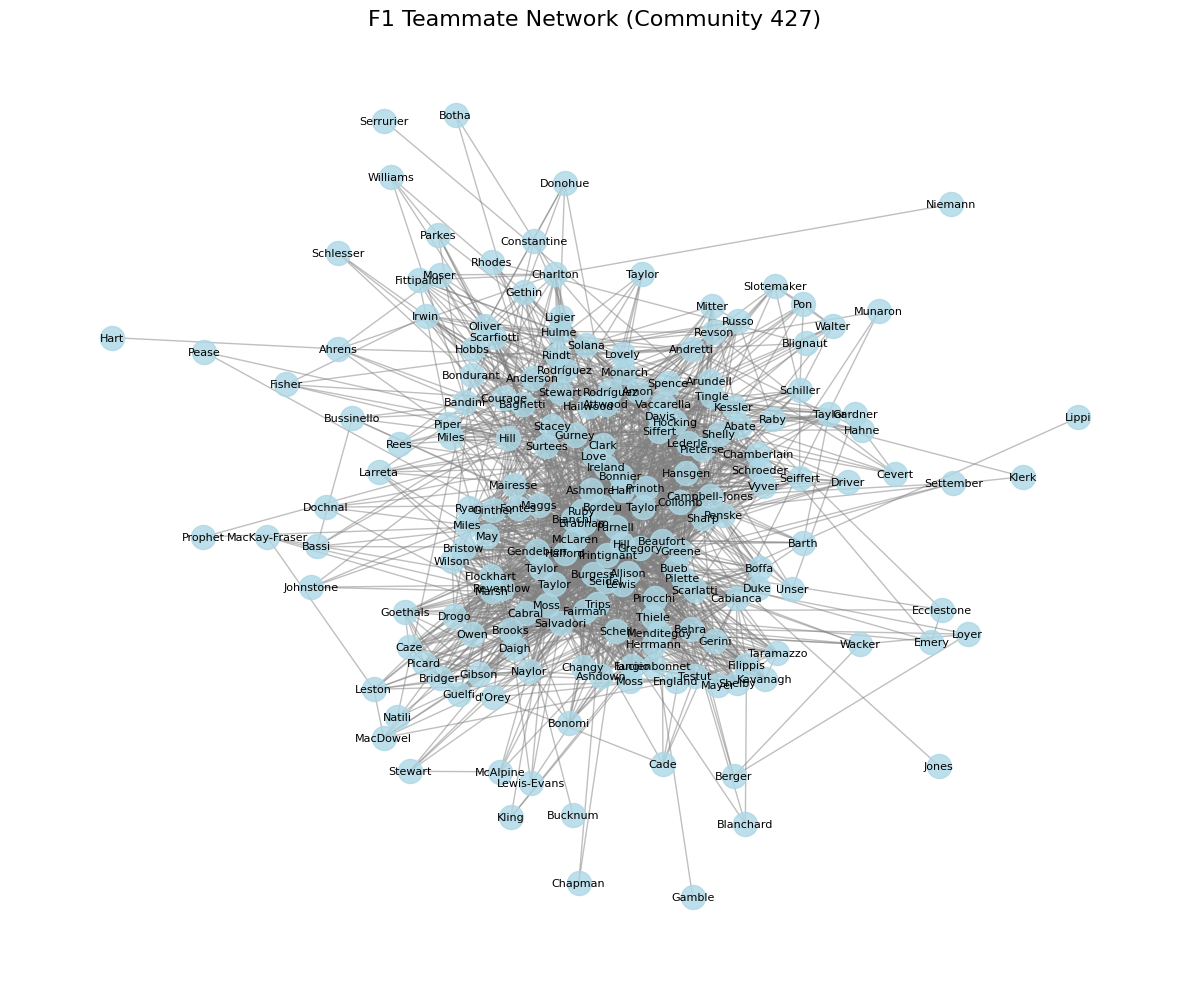

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Identify the label of the largest community
largest_community_label = (
    lpa_results.groupBy("label")
    .count()
    .orderBy(F.desc("count"))
    .first()["label"]
)

# 2. Filter Spark DataFrames to ONLY include nodes and edges in this community
community_nodes_spark = lpa_results.filter(F.col("label") == largest_community_label)

community_edges_spark = (
    edges.alias("e")
    .join(community_nodes_spark.alias("src_node"), F.col("e.src") == F.col("src_node.id"), "inner")
    .join(community_nodes_spark.alias("dst_node"), F.col("e.dst") == F.col("dst_node.id"), "inner")
    .select("e.src", "e.dst", "e.years_as_teammates")
)

# 3. Pull the highly filtered data into local memory (Pandas)
pdf_nodes = community_nodes_spark.select("id", "driver_name").toPandas()
pdf_edges = community_edges_spark.toPandas()

# 4. Build the NetworkX Graph
G = nx.Graph()

for index, row in pdf_nodes.iterrows():
    # Only use the last name to keep the plot clean
    last_name = row['driver_name'].split(" ")[-1]
    G.add_node(row['id'], label=last_name)

for index, row in pdf_edges.iterrows():
    G.add_edge(row['src'], row['dst'], weight=row['years_as_teammates'])

# 5. Draw the Graph
plt.figure(figsize=(12, 10))
# spring_layout clusters highly connected nodes together visually
pos = nx.spring_layout(G, k=0.5, seed=42)
labels = nx.get_node_attributes(G, 'label')

# Draw nodes, edges, and labels
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=300, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family="sans-serif")

plt.title(f"F1 Teammate Network (Community {largest_community_label})", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Connected Components: Isolated vs Connected Drivers

`connectedComponents()` assigns every vertex to a cluster where all nodes can reach each other through edges. In the F1 driver network a single giant component is expected — 74 years of team-mate chains connect almost everyone. Small or size-1 components represent drivers so historically isolated that no chain of team-mates links them to the main grid.

**Big-Data Note:** `connectedComponents()` is iterative. Without checkpointing, Spark builds an unbounded RDD lineage across iterations that causes OOM errors or extreme planning time on large graphs.

In [8]:
cc_results = f1_graph.connectedComponents()

component_sizes = (
    cc_results.groupBy("component")
    .agg(F.count("id").alias("driver_count"))
    .orderBy(F.desc("driver_count"))
)

print(f"Total distinct components: {component_sizes.count()}")
component_sizes.show(10)

Total distinct components: 28
+---------+------------+
|component|driver_count|
+---------+------------+
|        1|         826|
|      409|           3|
|      142|           2|
|      798|           2|
|      820|           2|
|      448|           2|
|      739|           2|
|      776|           2|
|      400|           1|
|      372|           1|
+---------+------------+
only showing top 10 rows



In [9]:
# Sample drivers from the largest connected component
largest_cc = component_sizes.first()["component"]

(
    cc_results
    .filter(F.col("component") == largest_cc)
    .orderBy("driver_name")
    .select("id", "driver_name", "nationality", "component")
    .show(20, truncate=False)
)

+---+-------------------------+-----------+---------+
|id |driver_name              |nationality|component|
+---+-------------------------+-----------+---------+
|750|Adolf Brudes             |German     |1        |
|698|Adolfo Cruz              |Argentine  |1        |
|16 |Adrian Sutil             |German     |1        |
|167|Adrián Campos            |Spanish    |1        |
|88 |Aguri Suzuki             |Japanese   |1        |
|538|Al Herman                |American   |1        |
|558|Al Keller                |American   |1        |
|371|Al Pease                 |Canadian   |1        |
|117|Alain Prost              |French     |1        |
|550|Alain de Changy          |Belgian    |1        |
|689|Alan Brown               |British    |1        |
|178|Alan Jones               |Australian |1        |
|390|Alan Rees                |British    |1        |
|502|Alan Stacey              |British    |1        |
|719|Albert Scherrer          |Swiss      |1        |
|647|Alberto Ascari         

## 9. Triangle Count: Tightly Embedded Hub Drivers

`triangleCount()` counts how many triangles pass through each node. A triangle exists when Driver A was a team-mate of B, B of C, and A also of C — a closed loop. High triangle count means deep cluster embeddedness, not just a high number of connections. These are the genuine hub drivers of F1 history rather than long-career journeymen.

In [10]:
triangle_results = f1_graph.triangleCount()

(
    triangle_results
    .orderBy(F.desc("count"))
    .select("id", "driver_name", "nationality", "count")
    .show(15, truncate=False)
)

+---+-------------------+-----------+-----+
|id |driver_name        |nationality|count|
+---+-------------------+-----------+-----+
|427|Maurice Trintignant|French     |1756 |
|475|Stirling Moss      |British    |1599 |
|356|Jack Brabham       |Australian |1510 |
|501|Harry Schell       |American   |1474 |
|593|Johnnie Parsons    |American   |1401 |
|456|Roy Salvadori      |British    |1370 |
|615|Fred Agabashian    |American   |1326 |
|418|Masten Gregory     |American   |1312 |
|611|Sam Hanks          |American   |1226 |
|555|Paul Russo         |American   |1196 |
|612|Andy Linden        |American   |1192 |
|556|Jimmy Daywalt      |American   |1122 |
|509|Jim Rathmann       |American   |1086 |
|526|Troy Ruttman       |American   |1073 |
|658|Jack McGrath       |American   |1069 |
+---+-------------------+-----------+-----+
only showing top 15 rows



## 10. Motif Finding: Cross-Team Bridge Drivers

The pattern `(a)-[e1]->(b); (b)-[e2]->(c)` finds all two-hop chains where Driver A was a team-mate of B, and B was a team-mate of C at a *different* constructor. This surfaces drivers who bridged team cultures or eras — the connectors who linked one chapter of F1 history to the next.

In [11]:
motifs = f1_graph.find("(a)-[e1]->(b); (b)-[e2]->(c)")

cross_team_bridges = (
    motifs
    .filter(F.col("a.id") != F.col("c.id"))
    .filter(F.col("e1.constructorId") != F.col("e2.constructorId"))
    .select(
        F.col("a.driver_name").alias("driver_A"),
        F.col("b.driver_name").alias("bridge_driver_B"),
        F.col("c.driver_name").alias("driver_C"),
        F.col("e1.years_as_teammates").alias("years_AB"),
        F.col("e2.years_as_teammates").alias("years_BC"),
    )
    .distinct()
    .orderBy((F.col("years_AB") + F.col("years_BC")).desc())
)

print(f"Total cross-team two-hop chains: {cross_team_bridges.count()}")
cross_team_bridges.show(20, truncate=False)

Total cross-team two-hop chains: 300216
+------------------+------------------+------------------+--------+--------+
|driver_A          |bridge_driver_B   |driver_C          |years_AB|years_BC|
+------------------+------------------+------------------+--------+--------+
|Rubens Barrichello|Michael Schumacher|Nico Rosberg      |6       |3       |
|Nico Rosberg      |Michael Schumacher|Rubens Barrichello|3       |6       |
|Riccardo Patrese  |Nigel Mansell     |Elio de Angelis   |4       |5       |
|Elio de Angelis   |Nigel Mansell     |Riccardo Patrese  |5       |4       |
|Jenson Button     |Rubens Barrichello|Michael Schumacher|3       |6       |
|Michael Schumacher|Rubens Barrichello|Jenson Button     |6       |3       |
|Mark Webber       |Sebastian Vettel  |Kimi Räikkönen    |5       |4       |
|Michael Schumacher|Rubens Barrichello|Eddie Irvine      |6       |3       |
|Kimi Räikkönen    |Sebastian Vettel  |Mark Webber       |4       |5       |
|Eddie Irvine      |Rubens Barrichel

---
## Graph 2 — Constructor Lineage DAG

F1 constructors have a rich history of acquisitions, rebranding events, and mergers. Mercedes traces through Tyrrell → BAR → Honda → Brawn GP → Mercedes. Alpine was Lotus F1 Team, then Renault, then Benetton. Red Bull bought Jaguar, which was Stewart GP. Aston Martin began as Jordan Grand Prix in 1991.

We model these events as a **directed acyclic graph (DAG)**:
- **Vertices** — constructors (historical and current)
- **Edges** — directed rebranding, acquisition, or split events

We then apply PageRank, ConnectedComponents, BFS, and Motif Finding.

In [12]:
# ── Vertices ────────────────────────────────────────────────────────────────
constructor_lin_vertices = spark.createDataFrame([
    ("tyrrell",      "Tyrrell",             "British"),
    ("bar",          "BAR",                 "British"),
    ("honda_f1",     "Honda",               "Japanese"),
    ("brawn",        "Brawn GP",            "British"),
    ("mercedes",     "Mercedes",            "German"),
    ("toleman",      "Toleman",             "British"),
    ("benetton",     "Benetton",            "Italian"),
    ("renault_2002", "Renault (2002-2011)", "French"),
    ("lotus_f1",     "Lotus F1 Team",       "British"),
    ("alpine",       "Alpine F1 Team",      "French"),
    ("stewart",      "Stewart GP",          "British"),
    ("jaguar_f1",    "Jaguar Racing",       "British"),
    ("red_bull",     "Red Bull Racing",     "Austrian"),
    ("minardi",      "Minardi",             "Italian"),
    ("toro_rosso",   "Toro Rosso",          "Italian"),
    ("alphatauri",   "AlphaTauri",          "Italian"),
    ("rb_f1",        "RB F1 Team",          "Italian"),
    ("jordan",       "Jordan Grand Prix",   "Irish"),
    ("midland",      "Midland F1",          "Russian"),
    ("spyker",       "Spyker F1",           "Dutch"),
    ("force_india",  "Force India",         "Indian"),
    ("racing_point", "Racing Point",        "Canadian"),
    ("aston_martin", "Aston Martin",        "British"),
    ("sauber_93",    "Sauber (1993-2005)",  "Swiss"),
    ("bmw_sauber",   "BMW Sauber",          "German"),
    ("sauber_10",    "Sauber (2010-2018)",  "Swiss"),
    ("alfa_romeo",   "Alfa Romeo Racing",   "Swiss"),
    ("kick_sauber",  "Kick Sauber",         "Swiss"),
    # Isolated constructors — no lineage edges
    ("ferrari",      "Ferrari",             "Italian"),
    ("mclaren",      "McLaren",             "British"),
    ("williams",     "Williams",            "British"),
    ("haas",         "Haas F1 Team",        "American"),
], ["id", "name", "nationality"])

# ── Edges ────────────────────────────────────────────────────────────────────
constructor_lin_edges = spark.createDataFrame([
    ("tyrrell",      "bar",          "acquisition"),
    ("bar",          "honda_f1",     "rebranding"),
    ("honda_f1",     "brawn",        "acquisition"),
    ("brawn",        "mercedes",     "acquisition"),
    ("toleman",      "benetton",     "acquisition"),
    ("benetton",     "renault_2002", "acquisition"),
    ("renault_2002", "lotus_f1",     "rebranding"),
    ("lotus_f1",     "alpine",       "rebranding"),
    ("stewart",      "jaguar_f1",    "acquisition"),
    ("jaguar_f1",    "red_bull",     "acquisition"),
    ("minardi",      "toro_rosso",   "acquisition"),
    ("toro_rosso",   "alphatauri",   "rebranding"),
    ("alphatauri",   "rb_f1",        "rebranding"),
    ("jordan",       "midland",      "acquisition"),
    ("midland",      "spyker",       "acquisition"),
    ("spyker",       "force_india",  "acquisition"),
    ("force_india",  "racing_point", "acquisition"),
    ("racing_point", "aston_martin", "rebranding"),
    ("sauber_93",    "bmw_sauber",   "acquisition"),
    ("bmw_sauber",   "sauber_10",    "rebranding"),
    ("sauber_10",    "alfa_romeo",   "rebranding"),
    ("alfa_romeo",   "kick_sauber",  "rebranding"),
], ["src", "dst", "relationship"])

# BIG-DATA NOTE: Cache before iterative algorithms
constructor_lin_vertices.cache()
constructor_lin_edges.cache()

constructor_graph = GraphFrame(constructor_lin_vertices, constructor_lin_edges)

print(f"Constructor Lineage Graph:")
print(f"  Vertices: {constructor_graph.vertices.count()}")
print(f"  Edges   : {constructor_graph.edges.count()}")
constructor_graph.vertices.show(truncate=False)
constructor_graph.edges.show(truncate=False)

Constructor Lineage Graph:
  Vertices: 32
  Edges   : 22
+------------+-------------------+-----------+
|id          |name               |nationality|
+------------+-------------------+-----------+
|tyrrell     |Tyrrell            |British    |
|bar         |BAR                |British    |
|honda_f1    |Honda              |Japanese   |
|brawn       |Brawn GP           |British    |
|mercedes    |Mercedes           |German     |
|toleman     |Toleman            |British    |
|benetton    |Benetton           |Italian    |
|renault_2002|Renault (2002-2011)|French     |
|lotus_f1    |Lotus F1 Team      |British    |
|alpine      |Alpine F1 Team     |French     |
|stewart     |Stewart GP         |British    |
|jaguar_f1   |Jaguar Racing      |British    |
|red_bull    |Red Bull Racing    |Austrian   |
|minardi     |Minardi            |Italian    |
|toro_rosso  |Toro Rosso         |Italian    |
|alphatauri  |AlphaTauri         |Italian    |
|rb_f1       |RB F1 Team         |Italian    |
|jo

### 11.1 PageRank: Most Influential Constructor Dynasties

A constructor scores highly if it received notable acquisitions from important predecessors. Mercedes — the end-point of a four-step dynasty — is expected to rank highest. Ferrari, McLaren, and Williams should score lower since no predecessor chains point to them.

**Big-Data Note:** `maxIter` is set explicitly — convergence tolerance alone produces non-deterministic runtimes on distributed graphs.

In [13]:
# BIG-DATA NOTE: maxIter set explicitly, never rely on convergence tolerance alone
constructor_pr = constructor_graph.pageRank(resetProbability=0.15, maxIter=10)

(
    constructor_pr.vertices
    .orderBy(F.desc("pagerank"))
    .select("id", "name", "nationality", F.round("pagerank", 4).alias("pagerank"))
    .show(20, truncate=False)
)

+------------+-------------------+-----------+--------+
|id          |name               |nationality|pagerank|
+------------+-------------------+-----------+--------+
|aston_martin|Aston Martin       |British    |1.8596  |
|racing_point|Racing Point       |Canadian   |1.6609  |
|kick_sauber |Kick Sauber        |Swiss      |1.6609  |
|alpine      |Alpine F1 Team     |French     |1.6609  |
|mercedes    |Mercedes           |German     |1.6609  |
|force_india |Force India        |Indian     |1.4271  |
|brawn       |Brawn GP           |British    |1.4271  |
|lotus_f1    |Lotus F1 Team      |British    |1.4271  |
|alfa_romeo  |Alfa Romeo Racing  |Swiss      |1.4271  |
|rb_f1       |RB F1 Team         |Italian    |1.4271  |
|spyker      |Spyker F1          |Dutch      |1.1521  |
|red_bull    |Red Bull Racing    |Austrian   |1.1521  |
|renault_2002|Renault (2002-2011)|French     |1.1521  |
|alphatauri  |AlphaTauri         |Italian    |1.1521  |
|sauber_10   |Sauber (2010-2018) |Swiss      |1.

### 11.2 Connected Components: Dynasties vs Isolated Constructors

`connectedComponents()` identifies which constructors belong to a lineage dynasty and which have always competed independently. Ferrari, McLaren, Williams, and Haas have no lineage edges and should each form a single-node component. The Mercedes, Alpine, Red Bull, RB, Aston Martin, and Sauber dynasties should each form one connected cluster.

In [14]:
spark.sparkContext.setCheckpointDir("/tmp/f1_constructor_checkpoint")

cc_constructors = constructor_graph.connectedComponents()

(
    cc_constructors
    .groupBy("component")
    .agg(
        F.count("id").alias("constructor_count"),
        F.concat_ws(", ", F.collect_list("name")).alias("constructors_in_dynasty")
    )
    .orderBy(F.desc("constructor_count"))
    .show(truncate=False)
)

+-------------+-----------------+----------------------------------------------------------------------------------+
|component    |constructor_count|constructors_in_dynasty                                                           |
+-------------+-----------------+----------------------------------------------------------------------------------+
|309237645312 |6                |Jordan Grand Prix, Midland F1, Spyker F1, Force India, Racing Point, Aston Martin |
|274877906944 |5                |Toleman, Benetton, Renault (2002-2011), Lotus F1 Team, Alpine F1 Team             |
|369367187456 |5                |Tyrrell, BAR, Honda, Brawn GP, Mercedes                                           |
|206158430208 |5                |Sauber (1993-2005), BMW Sauber, Sauber (2010-2018), Alfa Romeo Racing, Kick Sauber|
|1047972020225|4                |Minardi, Toro Rosso, AlphaTauri, RB F1 Team                                       |
|42949672960  |3                |Stewart GP, Jaguar Racing, Red 

### 11.3 BFS: Tracing the Mercedes Dynasty

BFS finds the shortest directed path from Tyrrell to Mercedes, tracing the exact chain of acquisitions and rebranding events. Expected path: Tyrrell → BAR → Honda → Brawn GP → Mercedes.

In [15]:
bfs_constructor = constructor_graph.bfs(
    fromExpr="id = 'tyrrell'",
    toExpr="id = 'mercedes'",
    maxPathLength=10
)

bfs_constructor.show(truncate=False)

# Print a readable dynasty chain
if bfs_constructor.count() > 0:
    row = bfs_constructor.first()
    vertex_cols = [c for c in bfs_constructor.columns if not c.startswith("e")]
    print("\n=== Mercedes Acquisition Chain ===")
    for col in vertex_cols:
        val = row[col]
        if val is not None:
            print(f"  -> {val['name']}")

+---------------------------+---------------------------+-------------------+---------------------------+---------------------------+------------------------------+--------------------------+------------------------------+----------------------------+
|from                       |e0                         |v1                 |e1                         |v2                         |e2                            |v3                        |e3                            |to                          |
+---------------------------+---------------------------+-------------------+---------------------------+---------------------------+------------------------------+--------------------------+------------------------------+----------------------------+
|{tyrrell, Tyrrell, British}|{tyrrell, bar, acquisition}|{bar, BAR, British}|{bar, honda_f1, rebranding}|{honda_f1, Honda, Japanese}|{honda_f1, brawn, acquisition}|{brawn, Brawn GP, British}|{brawn, mercedes, acquisition}|{mercedes, Mercedes, G

### 11.4 Motif Finding: Three-Generation Lineage Chains

The motif `(a)-[e1]->(b); (b)-[e2]->(c)` finds all three-node directed chains: a constructor that became another which then became a third. Examples: BAR → Honda → Brawn, Jordan → Midland → Spyker, Toleman → Benetton → Renault.

In [16]:
three_gen_motifs = constructor_graph.find("(a)-[e1]->(b); (b)-[e2]->(c)")

three_gen_chains = (
    three_gen_motifs
    .filter(F.col("a.id") != F.col("c.id"))
    .select(
        F.col("a.name").alias("generation_1"),
        F.col("e1.relationship").alias("event_1"),
        F.col("b.name").alias("generation_2"),
        F.col("e2.relationship").alias("event_2"),
        F.col("c.name").alias("generation_3"),
    )
    .distinct()
    .orderBy("generation_1", "generation_2")
)

three_gen_chains.show(truncate=False)

+-------------------+-----------+-------------------+-----------+-------------------+
|generation_1       |event_1    |generation_2       |event_2    |generation_3       |
+-------------------+-----------+-------------------+-----------+-------------------+
|BAR                |rebranding |Honda              |acquisition|Brawn GP           |
|BMW Sauber         |rebranding |Sauber (2010-2018) |rebranding |Alfa Romeo Racing  |
|Benetton           |acquisition|Renault (2002-2011)|rebranding |Lotus F1 Team      |
|Force India        |acquisition|Racing Point       |rebranding |Aston Martin       |
|Honda              |acquisition|Brawn GP           |acquisition|Mercedes           |
|Jordan Grand Prix  |acquisition|Midland F1         |acquisition|Spyker F1          |
|Midland F1         |acquisition|Spyker F1          |acquisition|Force India        |
|Minardi            |acquisition|Toro Rosso         |rebranding |AlphaTauri         |
|Renault (2002-2011)|rebranding |Lotus F1 Team      |r

---
## Graph 3 — Driver–Constructor Bipartite Network

A **bipartite graph** where vertices are either drivers or constructors, and an edge connects a driver to every constructor they raced for. Edge weight is total career points scored for that team.

PageRank surfaces constructors with the highest career-leverage score. Motif finding reveals which constructor pairs competed most often for the same drivers.

**Big-Data Note:** Driver and constructor IDs are prefixed (`d_` / `c_`) to prevent integer namespace collisions in the shared vertices DataFrame.

In [17]:
# ── Bipartite vertices ──────────────────────────────────────────────────────
driver_vertices_bip = dim_driver.select(
    F.concat(F.lit("d_"), F.col("driverId").cast("string")).alias("id"),
    F.col("driver_name").alias("name"),
    F.col("nationality"),
    F.lit("driver").alias("type")
)

constructor_vertices_bip = dim_constructor.select(
    F.concat(F.lit("c_"), F.col("constructorId").cast("string")).alias("id"),
    F.col("constructor_name").alias("name"),
    F.col("nationality"),
    F.lit("constructor").alias("type")
)

bipartite_vertices = driver_vertices_bip.union(constructor_vertices_bip)

# ── Bipartite edges ──────────────────────────────────────────────────────────
bipartite_edges = (
    fact_race_result
    .groupBy("driverId", "constructorId")
    .agg(
        F.sum("points").alias("total_points"),
        F.sum(F.when(F.col("position") == 1, 1).otherwise(0)).alias("wins"),
        F.countDistinct("year").alias("seasons_together"),
    )
    .select(
        F.concat(F.lit("d_"), F.col("driverId").cast("string")).alias("src"),
        F.concat(F.lit("c_"), F.col("constructorId").cast("string")).alias("dst"),
        "total_points", "wins", "seasons_together",
    )
)

# BIG-DATA NOTE: Cache before iterative algorithms
bipartite_vertices.cache()
bipartite_edges.cache()

bipartite_graph = GraphFrame(bipartite_vertices, bipartite_edges)

print(f"Bipartite Graph:")
print(f"  Vertices (drivers + constructors): {bipartite_graph.vertices.count()}")
print(f"  Edges (driver-team pairings)     : {bipartite_graph.edges.count()}")

Bipartite Graph:
  Vertices (drivers + constructors): 1073
  Edges (driver-team pairings)     : 2150


### 12.1 PageRank: Which Constructors Most Amplified Driver Careers?

A constructor scores highly if it was connected to many high-scoring drivers, and those drivers were connected to many other well-connected constructors. This is the career-leverage score: the teams that winning careers ran through.

In [18]:
# BIG-DATA NOTE: maxIter set explicitly
bip_pr = bipartite_graph.pageRank(resetProbability=0.15, maxIter=10)

print("=== Top Constructors by PageRank (career leverage score) ===")
(
    bip_pr.vertices
    .filter(F.col("type") == "constructor")
    .orderBy(F.desc("pagerank"))
    .select("id", "name", "nationality", F.round("pagerank", 4).alias("pagerank"))
    .show(15, truncate=False)
)

print("\n=== Top Drivers by PageRank (career leverage score) ===")
(
    bip_pr.vertices
    .filter(F.col("type") == "driver")
    .orderBy(F.desc("pagerank"))
    .select("id", "name", "nationality", F.round("pagerank", 4).alias("pagerank"))
    .show(15, truncate=False)
)

=== Top Constructors by PageRank (career leverage score) ===
+-----+-------------+-----------+--------+
|id   |name         |nationality|pagerank|
+-----+-------------+-----------+--------+
|c_105|Maserati     |Italian    |25.9897 |
|c_113|Kurtis Kraft |American   |25.428  |
|c_6  |Ferrari      |Italian    |18.0369 |
|c_172|Lotus-Climax |British    |13.6499 |
|c_170|Cooper-Climax|British    |13.5821 |
|c_3  |Williams     |British    |12.9565 |
|c_32 |Team Lotus   |British    |12.4825 |
|c_66 |BRM          |British    |12.4728 |
|c_87 |Cooper       |British    |10.5102 |
|c_125|Connaught    |British    |10.3534 |
|c_18 |Minardi      |Italian    |10.2833 |
|c_34 |Brabham      |British    |9.3452  |
|c_1  |McLaren      |British    |9.0865  |
|c_37 |March        |British    |8.8136  |
|c_25 |Tyrrell      |British    |8.7825  |
+-----+-------------+-----------+--------+
only showing top 15 rows


=== Top Drivers by PageRank (career leverage score) ===
+-----+----------------------+---------

### 12.2 Motif Finding: Constructor Pairs Competing for the Same Drivers

The pattern finds pairs of constructors that both recruited the same driver. A high shared-driver count between two constructors signals direct rivalry in the driver market.

We reverse edge direction (constructor → driver) so both edges share the same destination node.

In [19]:
# Reverse edges: constructor -> driver
bip_edges_reversed = bipartite_edges.select(
    F.col("dst").alias("src"),
    F.col("src").alias("dst"),
    "total_points", "wins", "seasons_together"
)

bipartite_graph_rev = GraphFrame(bipartite_vertices, bip_edges_reversed)

# Motif: two constructors pointing to the same driver vertex
shared_motifs = bipartite_graph_rev.find("(c1)-[e1]->(d); (c2)-[e2]->(d)")

shared_driver_pairs = (
    shared_motifs
    .filter(F.col("c1.type") == "constructor")
    .filter(F.col("c2.type") == "constructor")
    .filter(F.col("d.type") == "driver")
    .filter(F.col("c1.id") < F.col("c2.id"))   # deduplicate (A,B) vs (B,A)
    .select(
        F.col("c1.name").alias("constructor_1"),
        F.col("c2.name").alias("constructor_2"),
        F.col("d.name").alias("shared_driver"),
    )
    .distinct()
    .groupBy("constructor_1", "constructor_2")
    .agg(
        F.count("shared_driver").alias("shared_driver_count"),
        F.concat_ws(", ", F.collect_list("shared_driver")).alias("sample_drivers")
    )
    .orderBy(F.desc("shared_driver_count"))
)

shared_driver_pairs.show(15, truncate=False)

+---------------+-------------+-------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|constructor_1  |constructor_2|shared_driver_count|sample_drivers                                                                                                                                                                                                                                                                                                                                |
+---------------+-------------+-------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

---
## Summary — GraphFrames Components Demonstrated

| Section | Feature | Graph | Business Insight |
|---|---|---|---|
| 4 | `pageRank()` | Driver teammate network | Most central drivers in F1 history |
| 5 | `labelPropagation()` | Driver teammate network | Era-based driver communities |
| 6 | BFS | Driver teammate network | Degrees of separation (Senna → Verstappen) |
| 7 | NetworkX visualisation | Driver teammate network | Community structure |
| 8 | `connectedComponents()` | Driver teammate network | Isolated vs connected drivers |
| 9 | `triangleCount()` | Driver teammate network | Tightly embedded hub drivers |
| 10 | Motif `(a)-[e1]->(b); (b)-[e2]->(c)` | Driver teammate network | Cross-team bridge drivers |
| 11.1 | `pageRank()` | Constructor lineage DAG | Most influential dynasties |
| 11.2 | `connectedComponents()` | Constructor lineage DAG | Dynasty vs isolated constructor |
| 11.3 | BFS | Constructor lineage DAG | Tyrrell → Mercedes acquisition chain |
| 11.4 | Motif `(a)-[e1]->(b); (b)-[e2]->(c)` | Constructor lineage DAG | Three-generation lineages |
| 12.1 | `pageRank()` | Driver–constructor bipartite | Constructor career-leverage score |
| 12.2 | Motif (shared destination) | Driver–constructor bipartite | Constructor pairs sharing drivers |

**Big-Data Safety Applied:**
- `vertices.cache()` and `edges.cache()` before every iterative algorithm on all three graphs
- `spark.sparkContext.setCheckpointDir()` set before every `connectedComponents()` call
- `maxIter` specified explicitly on all `pageRank()` calls — no convergence-tolerance guessing
- `.toPandas()` called only after aggressive Spark-side filtering (Section 7 NetworkX visualisation)